In [14]:
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import cv2
import numpy as np
import os
import json

# Global variables for drawing the line
drawing = False
line_start = None
line_end = None
scale = None

def draw_line(event, x, y, flags, param):
    global drawing, line_start, line_end
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        line_start = (x, y)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        line_end = (x, y)
        cv2.line(param, line_start, line_end, (0, 255, 0), 2)
        cv2.imshow("Image", param)

def calculate_scale(image, real_distance):
    global line_start, line_end, scale
    print("Draw a line on the image and press any key when done.")
    cv2.imshow("Image", image)
    cv2.setMouseCallback("Image", draw_line, param=image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if line_start and line_end:
        pixel_distance = np.sqrt((line_end[0] - line_start[0])**2 + (line_end[1] - line_start[1])**2)
        scale = real_distance / pixel_distance
        print(f"Scale calculated: {scale} units per pixel.")
    else:
        print("No line was drawn. Exiting.")
        exit()

def process_image(image_path, output_folder, real_distance):
    global scale
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return []

    # Prompt the user to draw a line and calculate the scale
    if scale is None:
        calculate_scale(image.copy(), real_distance)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Label connected components in the edge image
    num_labels, labels = cv2.connectedComponents(edges)

    # Create a blank output image
    output_image = np.zeros_like(image)

    edge_data = []  # To store data for each edge

    for label in range(1, num_labels):  # Skip the background label (0)
        # Extract points belonging to the current edge
        edge_points = np.argwhere(labels == label)

        # Convert pixel coordinates to real-world coordinates
        real_world_points = [(x * scale, y * scale) for x, y in edge_points]

        # Calculate the length of the edge
        edge_length = len(edge_points) * scale

        # Calculate the average contrast of the edge
        contrast_values = [gray[x, y] for x, y in edge_points]
        avg_contrast = np.mean(contrast_values)

        # Fit a parametric curve to the real-world points
        real_world_points = np.array(real_world_points)
        x_coords = real_world_points[:, 1]  # Real-world x-coordinates
        y_coords = real_world_points[:, 0]  # Real-world y-coordinates

        if len(x_coords) > 2:  # Ensure there are enough points to fit a curve
            # Normalize the parameter t (arc length)
            t = np.linspace(0, 1, len(x_coords))

            # Fit cubic splines for x(t) and y(t)
            spline_x = CubicSpline(t, x_coords)
            spline_y = CubicSpline(t, y_coords)

            # Extract coefficients for each segment
            x_t = spline_x.c.T.tolist()  # Transpose to match the expected format
            y_t = spline_y.c.T.tolist()

            # Calculate the translation (centroid of the edge)
            translation_x = np.mean(x_coords)
            translation_y = np.mean(y_coords)

            # Store the parametric representation and translation
            edge_data.append({
                "length": edge_length,
                "avg_contrast": avg_contrast,
                "parametric": {
                    "t": t.tolist(),  # Parameter values
                    "x_t": x_t,  # Coefficients of the spline for x(t)
                    "y_t": y_t   # Coefficients of the spline for y(t)
                },
                "translation": [translation_x, translation_y]  # Store the translation
            })
            print(f"Edge {label}: Length = {edge_length:.2f} units, Avg Contrast = {avg_contrast:.2f}")
            print(f"Translation: ({translation_x:.2f}, {translation_y:.2f})")
        else:
            print(f"Edge {label}: Not enough points to fit a curve.")

        # Draw the edge on the output image
        for x, y in edge_points:
            output_image[x, y] = (255, 255, 255)  # Draw edges in white

    # Save the output image
    output_path = os.path.join(output_folder, f"processed_{os.path.basename(image_path)}")
    cv2.imwrite(output_path, output_image)
    print(f"Processed and saved: {output_path}")

    # Save the edge data to a JSON file
    json_output_path = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(image_path))[0]}_edges.json")
    with open(json_output_path, 'w') as json_file:
        json.dump(edge_data, json_file, indent=4)
    print(f"Edge data saved to: {json_output_path}")

    return edge_data

def process_folder(folder_path, output_folder, real_distance):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            process_image(os.path.join(folder_path, filename), output_folder, real_distance)

In [15]:
# Example usage
small_image_path = "test-cans/8.16x4.83/pepsi.png"
small_image_width = 8.16  # Width of the smaller image in inches
output_folder = "output_folder_for_edges"
os.makedirs(output_folder, exist_ok=True)

# Process the image and save edge data
edge_data = process_image(small_image_path, output_folder, real_distance=small_image_width)

Draw a line on the image and press any key when done.
Scale calculated: 0.011173459864151225 units per pixel.
Edge 1: Length = 25.25 units, Avg Contrast = 113.22
Translation: (4.10, 2.22)
Edge 2: Length = 8.18 units, Avg Contrast = 95.02
Translation: (7.04, 1.14)
Edge 3: Length = 6.55 units, Avg Contrast = 123.17
Translation: (7.27, 1.07)
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Translation: (7.94, 0.11)
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Translation: (7.97, 0.15)
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Translation: (6.69, 0.19)
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Translation: (6.82, 0.21)
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Translation: (6.91, 0.21)
Edge 9: Length = 0.08 units, Avg Contrast = 98.86
Translation: (7.01, 0.14)
Edge 10: Length = 1.55 units, Avg Contrast = 104.40
Translation: (7.16, 0.23)
Edge 11: Length = 0.26 units, Avg Contrast = 109.39
Translation: (7.42, 0.16)
Edge 12: Length = 0.96 units, Avg Contrast

In [18]:
# Example usage
folder_path = 'test-cans/8.16x4.83/'  # Replace with your folder path
single_image_path = 'test-cans/8.16x4.83/pepsi.png'  # Replace with your single image path
output_folder = 'output-images/'  # Replace with your output folder path
real_distance = 8.16  # Replace with the real-world distance for the drawn line

# Process a folder of images
#process_folder(folder_path, output_folder, real_distance)

# Process a single image
process_image(single_image_path, output_folder, real_distance)

Draw a line on the image and press any key when done.
Scale calculated: 0.01117804024012286 units per pixel.
Edge 1: Length = 25.26 units, Avg Contrast = 113.22
Polynomial coefficients: [-3.00637807e-16  4.10869981e-15  2.21884099e+00]
Edge 2: Length = 8.18 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.40092849 -20.09692772  72.50003131]
Edge 3: Length = 6.55 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02819189 -0.31541817  1.86895831]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.85498184   554.88311676 -2208.27657779]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.59988812 -169.21677355  675.48575516]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.84882002 -655.29875382 2197.82868772]
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.20127981  153.18947999 -523.52443419]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65


C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 114: Length = 0.04 units, Avg Contrast = 195.75
Polynomial coefficients: [0.00700326 0.04258578 0.25895793]
Edge 115: Length = 0.32 units, Avg Contrast = 95.76
Polynomial coefficients: [  -3.39184924   48.99543404 -176.13502309]
Edge 116: Length = 0.06 units, Avg Contrast = 64.00
Polynomial coefficients: [0.00494065 0.03589744 0.26082094]
Edge 117: Length = 0.11 units, Avg Contrast = 64.80
Polynomial coefficients: [-2.51838551e-08  3.67647047e-07  7.88050495e-01]
Edge 118: Length = 3.77 units, Avg Contrast = 100.49
Polynomial coefficients: [ 0.19384805 -2.77869776 10.79380151]
Edge 119: Length = 0.73 units, Avg Contrast = 107.38
Polynomial coefficients: [-0.09419609  1.50567134 -5.20887011]
Edge 120: Length = 0.08 units, Avg Contrast = 117.29
Polynomial coefficients: [  -22.36528002   347.74999999 -1350.98912142]
Edge 121: Length = 0.03 units, Avg Contrast = 193.67
Polynomial coefficients: [0.04915334 0.11483254 0.26827297]
Edge 122: Length = 0.03 units, Avg Contrast = 196.67
Poly

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 320: Length = 0.65 units, Avg Contrast = 114.12
Polynomial coefficients: [ 0.0785801  -1.05288782  5.29532963]
Edge 321: Length = 2.39 units, Avg Contrast = 114.97
Polynomial coefficients: [ -0.92927519  13.54826303 -47.55642786]
Edge 322: Length = 0.38 units, Avg Contrast = 124.68
Polynomial coefficients: [  0.74830803 -11.39570378  45.17076196]
Edge 323: Not enough points to fit a curve.
Edge 324: Length = 0.26 units, Avg Contrast = 120.65
Polynomial coefficients: [ -1.24021717  17.03343129 -56.68017568]
Edge 325: Not enough points to fit a curve.
Edge 326: Length = 0.75 units, Avg Contrast = 115.88
Polynomial coefficients: [ -0.92861702  12.57493872 -40.69991601]
Edge 327: Length = 0.06 units, Avg Contrast = 73.60
Polynomial coefficients: [0.01283624 0.0891036  0.61851823]
Edge 328: Length = 0.38 units, Avg Contrast = 91.68
Polynomial coefficients: [  0.72837827 -10.21165316  37.66288121]
Edge 329: Length = 0.17 units, Avg Contrast = 122.60
Polynomial coefficients: [  4.3549555

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 511: Length = 0.03 units, Avg Contrast = 197.67
Polynomial coefficients: [-1.41851410e-12  2.55050450e-12  2.99571478e+00]
Edge 512: Length = 0.34 units, Avg Contrast = 179.60
Polynomial coefficients: [  648.59312047 -1225.25000002   581.63814586]
Edge 513: Length = 0.03 units, Avg Contrast = 200.00
Polynomial coefficients: [ 4.68570590e-12 -1.04199379e-11  2.99571478e+00]
Edge 514: Length = 0.55 units, Avg Contrast = 212.29
Polynomial coefficients: [  550.31368999 -1265.564        730.57653853]
Edge 515: Length = 0.95 units, Avg Contrast = 152.38
Polynomial coefficients: [ -7.2059515   21.49815846 -12.83873551]
Edge 516: Length = 0.25 units, Avg Contrast = 135.23
Polynomial coefficients: [  12.72869628 -172.77449664  589.38647827]
Edge 517: Length = 0.47 units, Avg Contrast = 168.83
Polynomial coefficients: [  3.50533645 -52.60342102 200.45011289]
Edge 518: Not enough points to fit a curve.
Edge 519: Not enough points to fit a curve.
Edge 520: Not enough points to fit a curve.
Ed

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve


[{'length': 25.262370942677663,
  'avg_contrast': 113.22433628318583,
  'coefficients': array([-3.00637807e-16,  4.10869981e-15,  2.21884099e+00]),
  'x_coords': array([0.        , 0.01117804, 0.02235608, ..., 8.17114742, 8.18232546,
         8.1935035 ]),
  'y_coords': array([0.        , 0.        , 0.        , ..., 4.43768198, 4.43768198,
         4.43768198])},
 {'length': 8.182325455769933,
  'avg_contrast': 95.01912568306011,
  'coefficients': array([  1.40092849, -20.09692772,  72.50003131]),
  'x_coords': array([6.61739982, 6.62857786, 6.6397559 , 6.65093394, 6.66211198,
         6.67329002, 6.68446806, 6.6956461 , 6.70682414, 6.71800218,
         6.72918022, 6.74035826, 6.75153631, 6.76271435, 6.77389239,
         6.78507043, 6.79624847, 6.80742651, 6.81860455, 6.82978259,
         6.84096063, 6.85213867, 6.86331671, 6.87449475, 6.88567279,
         6.89685083, 6.90802887, 6.91920691, 6.93038495, 6.94156299,
         6.95274103, 6.96391907, 6.97509711, 6.98627515, 6.99745319,
 

Edge 1: Length = 25.26 units, Avg Contrast = 113.22
Polynomial coefficients: [-3.00637807e-16  4.10869981e-15  2.21884099e+00]
Edge 2: Length = 8.18 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.40092849 -20.09692772  72.50003131]
Edge 3: Length = 6.55 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02819189 -0.31541817  1.86895831]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.85498184   554.88311676 -2208.27657779]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.59988812 -169.21677355  675.48575516]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.84882002 -655.29875382 2197.82868772]
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.20127981  153.18947999 -523.52443419]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Polynomial coefficients: [  17.78448381 -245.55151658  847.786541  ]
Edge 9: Length = 0.08 units, Avg Contras

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 203: Length = 0.08 units, Avg Contrast = 190.57
Polynomial coefficients: [ 2.91699820e-13 -2.63373697e-12  1.11780402e+00]
Edge 204: Length = 0.03 units, Avg Contrast = 209.67
Polynomial coefficients: [ 1.83461803e-13 -1.68346094e-12  1.11780402e+00]
Edge 205: Not enough points to fit a curve.
Edge 206: Length = 0.03 units, Avg Contrast = 200.67
Polynomial coefficients: [0.01044446 0.06269398 0.37632735]
Edge 207: Length = 0.06 units, Avg Contrast = 105.40
Polynomial coefficients: [-0.00423378  0.05645918  0.94075572]
Edge 208: Length = 0.03 units, Avg Contrast = 104.00
Polynomial coefficients: [0.0075167  0.05318589 0.37632735]
Edge 209: Length = 0.03 units, Avg Contrast = 196.67
Polynomial coefficients: [0.02277685 0.09394761 0.38750539]
Edge 210: Length = 2.46 units, Avg Contrast = 95.19
Polynomial coefficients: [ 0.00399626 -0.05809684  1.39512458]
Edge 211: Length = 0.03 units, Avg Contrast = 197.33
Polynomial coefficients: [0.07823964 0.17578773 0.39495742]
Edge 212: Length 

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 417: Length = 0.86 units, Avg Contrast = 113.44
Polynomial coefficients: [ 0.5652713  -8.44809517 33.90723347]
Edge 418: Length = 0.46 units, Avg Contrast = 102.83
Polynomial coefficients: [  4.19761518 -64.78291709 252.31694417]
Edge 419: Length = 0.34 units, Avg Contrast = 106.83
Polynomial coefficients: [  -4.31954808   67.87069745 -264.23621432]
Edge 420: Length = 2.69 units, Avg Contrast = 79.36
Polynomial coefficients: [ 4.94310517 -7.56123378  4.73068884]
Edge 421: Length = 0.18 units, Avg Contrast = 110.31
Polynomial coefficients: [  2.88381405 -39.78397761 139.59633745]
Edge 422: Length = 0.08 units, Avg Contrast = 75.29
Polynomial coefficients: [   89.46112009 -1262.00000033  4453.0182477 ]
Edge 423: Not enough points to fit a curve.
Edge 424: Length = 0.08 units, Avg Contrast = 116.14
Polynomial coefficients: [  178.92224005 -2663.99999878  9918.52101741]
Edge 425: Not enough points to fit a curve.
Edge 426: Not enough points to fit a curve.
Edge 427: Not enough points 

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 616: Length = 0.82 units, Avg Contrast = 113.14
Polynomial coefficients: [  1.92431694 -20.19217689  56.96813413]
Edge 617: Length = 0.27 units, Avg Contrast = 128.29
Polynomial coefficients: [ -23.63722602  250.26147892 -658.42206438]
Edge 618: Length = 1.26 units, Avg Contrast = 119.11
Polynomial coefficients: [ -2.83456185  31.59811188 -84.05214055]
Edge 619: Length = 0.25 units, Avg Contrast = 103.91
Polynomial coefficients: [  45.27428024 -530.89402498 1560.32214114]
Edge 620: Length = 1.73 units, Avg Contrast = 207.72
Polynomial coefficients: [-5.28398244e-15  7.87519927e-14  3.94584820e+00]
Edge 621: Not enough points to fit a curve.
Edge 622: Length = 0.28 units, Avg Contrast = 131.04
Polynomial coefficients: [  3.62855351 -40.22925141 115.47859705]
Edge 623: Length = 0.79 units, Avg Contrast = 107.77
Polynomial coefficients: [  -5.36346089   70.56612257 -228.01956569]
Edge 624: Length = 0.15 units, Avg Contrast = 220.85
Polynomial coefficients: [  5.10706449 -81.85430315 

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve


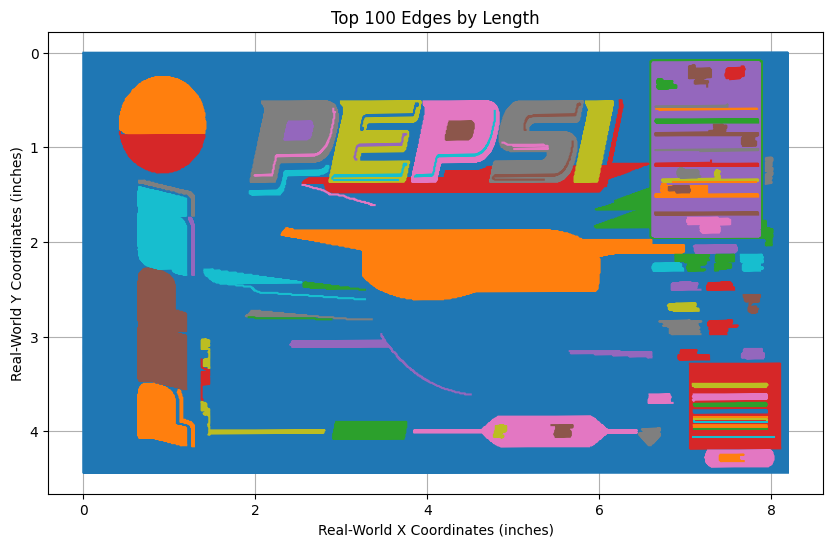

In [19]:
import matplotlib.pyplot as plt

# Process the image and get edge data
edge_data = process_image(single_image_path, output_folder, real_distance)

# Sort edges by length in descending order
sorted_edges = sorted(edge_data, key=lambda e: e["length"], reverse=True)

# Number of edges to plot
x = 100  # Replace with the desired number of edges to plot

# Plot the first x edges
plt.figure(figsize=(10, 6))
for i, edge in enumerate(sorted_edges[:x]):
    plt.plot(edge["x_coords"], edge["y_coords"], label=f"Edge {i+1} (Length: {edge['length']:.2f} inches)")

plt.title(f"Top {x} Edges by Length")
plt.xlabel("Real-World X Coordinates (inches)")
plt.ylabel("Real-World Y Coordinates (inches)")
plt.gca().invert_yaxis()  # Invert the y-axis to match the image coordinate system
#plt.legend()
plt.grid()
plt.show()

In [20]:
def segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size=100):
    """
    Segments an image into clusters of connected pixels with similar colors.

    Args:
        image_path (str): Path to the input image.
        color_threshold (float): Threshold for color similarity (lower = stricter).
        output_folder (str): Path to save the segmented output images.
        min_cluster_size (int): Minimum number of pixels for a cluster to be saved.

    Returns:
        np.ndarray: The segmented image with outlined clusters.
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return

    # Convert the image to LAB color space (better for color similarity)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Create a blank canvas for the segmented image
    segmented_image = np.zeros_like(image)

    # Create a mask to track visited pixels
    visited = np.zeros(image_lab.shape[:2], dtype=bool)

    # Create an output folder
    os.makedirs(output_folder, exist_ok=True)

    # Cluster counter
    cluster_id = 0

    # Prepare for plotting
    fig, axes = plt.subplots(3, 5, figsize=(20, 15))  # Plot up to 15 clusters
    axes = axes.flatten()  # Flatten the 2D array into a 1D array
    plotted_clusters = 0

    # Iterate over each pixel in the image
    for y in range(image_lab.shape[0]):
        for x in range(image_lab.shape[1]):
            if visited[y, x]:
                continue

            # Start a new cluster
            cluster_mask = np.zeros(image_lab.shape[:2], dtype=bool)
            cluster_color = image_lab[y, x]

            # Perform region growing to find connected pixels with similar colors
            stack = [(y, x)]
            while stack:
                cy, cx = stack.pop()
                if visited[cy, cx]:
                    continue

                visited[cy, cx] = True
                cluster_mask[cy, cx] = True

                # Check neighbors
                for ny, nx in [(cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)]:
                    if 0 <= ny < image_lab.shape[0] and 0 <= nx < image_lab.shape[1]:
                        if not visited[ny, nx]:
                            neighbor_color = image_lab[ny, nx]
                            color_distance = np.linalg.norm(cluster_color - neighbor_color)
                            if color_distance < color_threshold:
                                stack.append((ny, nx))

            # Check if the cluster meets the minimum size requirement
            cluster_size = np.sum(cluster_mask)
            if cluster_size < min_cluster_size:
                continue  # Skip small clusters

            # Assign a random color to the cluster
            random_color = np.random.randint(0, 255, size=3, dtype=np.uint8)
            segmented_image[cluster_mask] = random_color

            # Save the cluster as an individual image
            cluster_image = np.zeros_like(image)
            cluster_image[cluster_mask] = image[cluster_mask]
            cluster_path = os.path.join(output_folder, f"cluster_{cluster_id + 1}.jpg")
            cv2.imwrite(cluster_path, cluster_image)
            print(f"Cluster {cluster_id + 1} saved to: {cluster_path}")

            # Plot the cluster (up to 15 clusters)
            if plotted_clusters < len(axes):
                axes[plotted_clusters].imshow(cv2.cvtColor(cluster_image, cv2.COLOR_BGR2RGB))
                axes[plotted_clusters].set_title(f"Cluster {cluster_id + 1}")
                axes[plotted_clusters].axis("off")
                plotted_clusters += 1

            cluster_id += 1

    # Save the final segmented image
    segmented_image_path = os.path.join(output_folder, "segmented_image.jpg")
    cv2.imwrite(segmented_image_path, segmented_image)
    print(f"Segmented image saved to: {segmented_image_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()

    return segmented_image

Cluster 1 saved to: output-images-colors\cluster_1.jpg
Cluster 2 saved to: output-images-colors\cluster_2.jpg
Cluster 3 saved to: output-images-colors\cluster_3.jpg
Cluster 4 saved to: output-images-colors\cluster_4.jpg
Cluster 5 saved to: output-images-colors\cluster_5.jpg
Cluster 6 saved to: output-images-colors\cluster_6.jpg
Cluster 7 saved to: output-images-colors\cluster_7.jpg
Cluster 8 saved to: output-images-colors\cluster_8.jpg
Cluster 9 saved to: output-images-colors\cluster_9.jpg
Cluster 10 saved to: output-images-colors\cluster_10.jpg
Cluster 11 saved to: output-images-colors\cluster_11.jpg
Cluster 12 saved to: output-images-colors\cluster_12.jpg
Cluster 13 saved to: output-images-colors\cluster_13.jpg
Cluster 14 saved to: output-images-colors\cluster_14.jpg
Segmented image saved to: output-images-colors\segmented_image.jpg


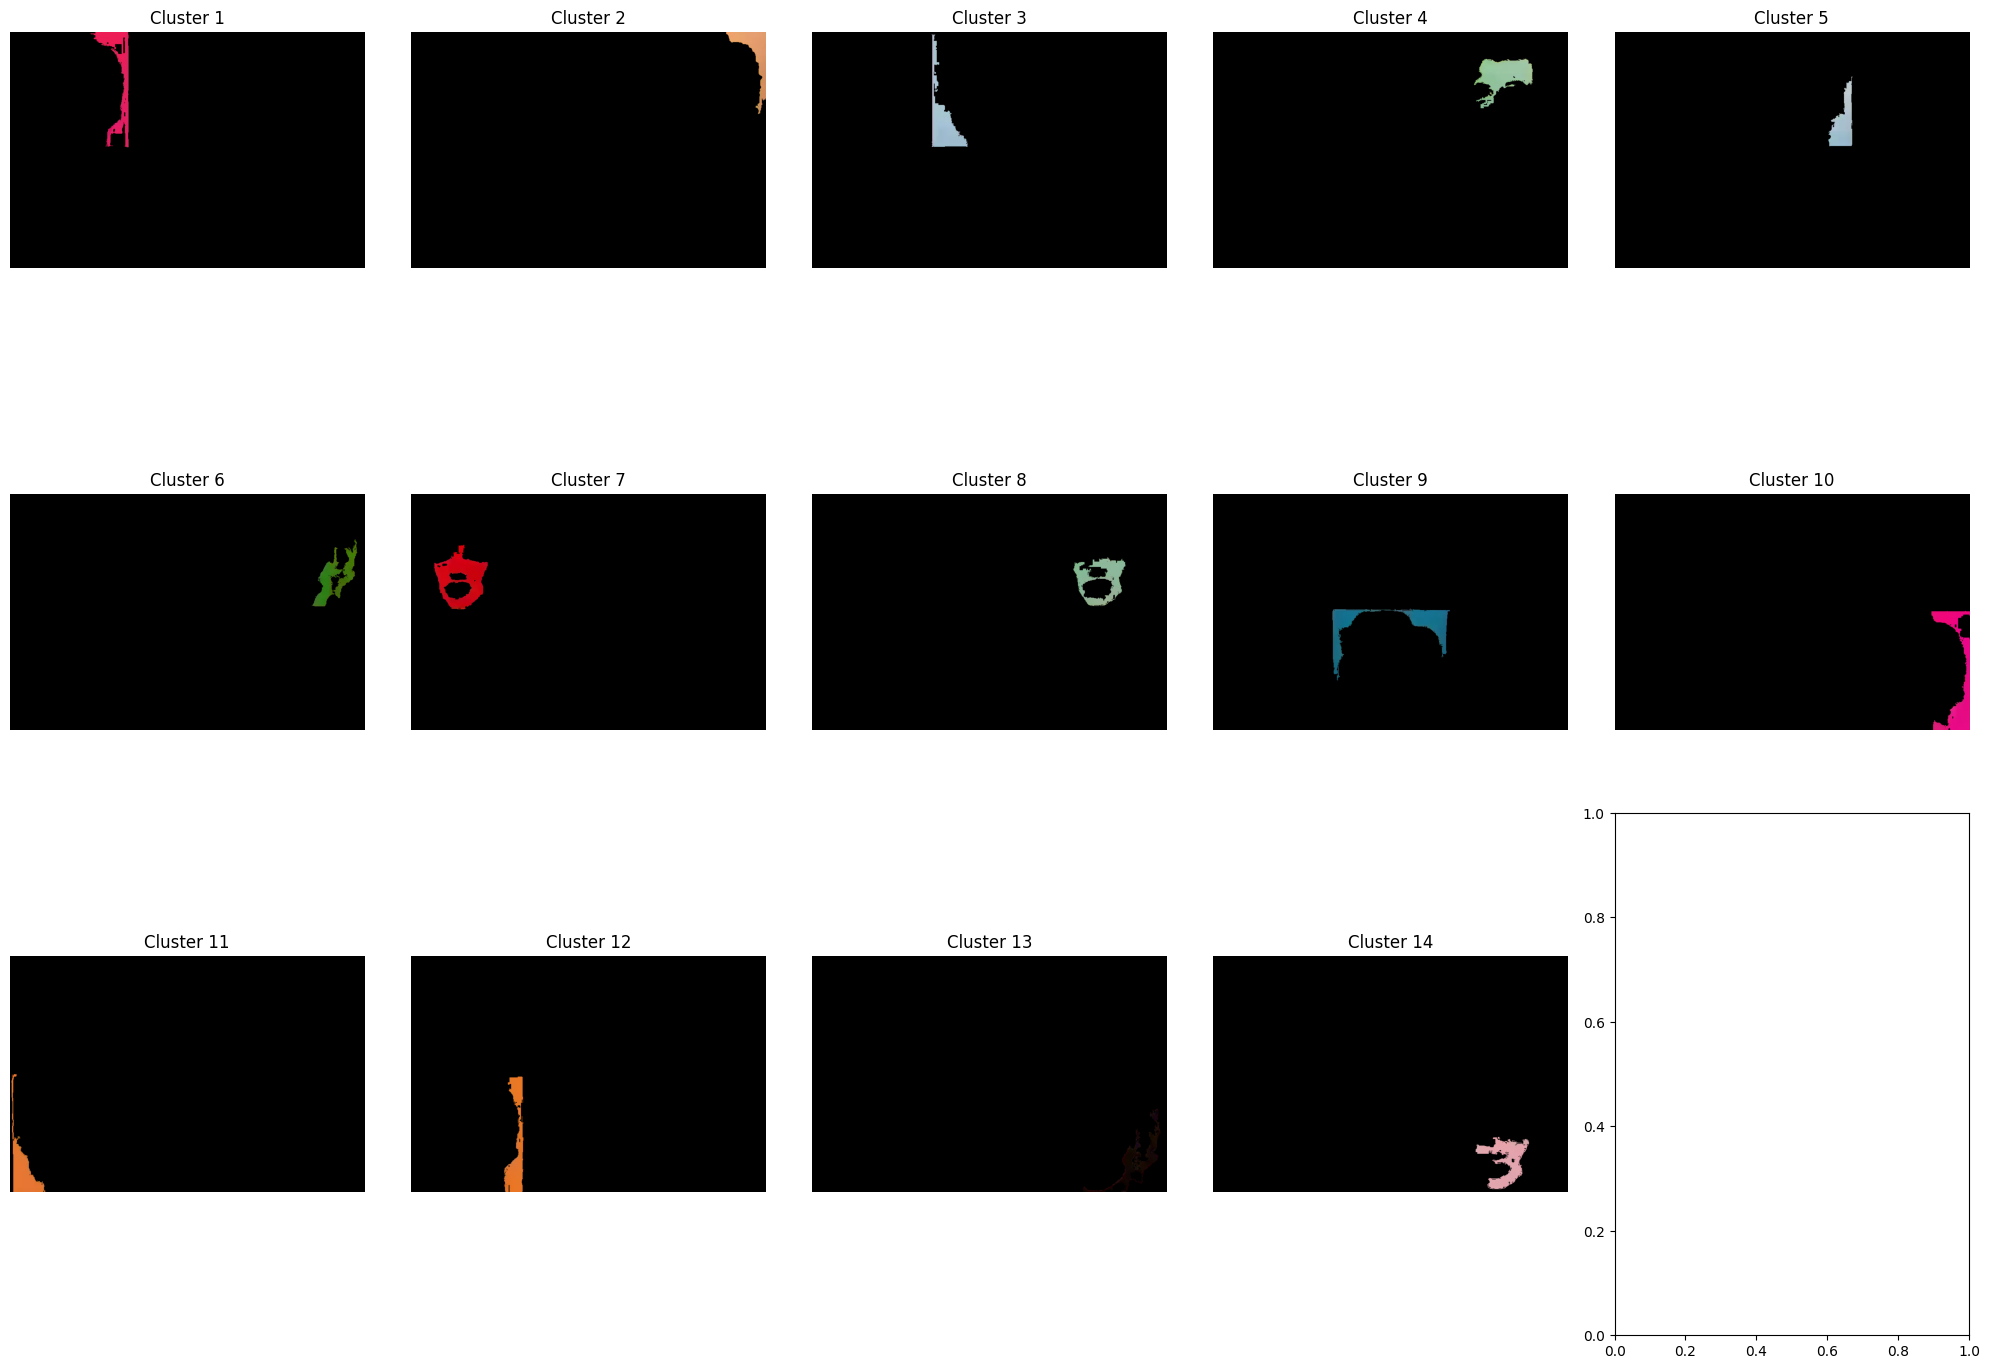

In [ ]:
# Example usage
image_path = "test-images/mm.png"  # Replace with your image path
output_folder = "output-images-colors"  # Replace with your output folder path
color_threshold = 30.0  # Adjust for stricter or looser color similarity
min_cluster_size = 5000  # Minimum size of clusters to save

segmented_image = segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size)

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist

def create_mosaic_from_polynomial_curves(
    small_image_edges, large_image_path, large_image_width, process_image_function
):
    """
    Recreates the edges of the larger image using the edges of the smaller image.

    Args:
        small_image_edges (list): List of edges from the smaller image, where each edge contains
                                  polynomial coefficients, x and y coordinates, and other metadata.
        large_image_path (str): Path to the larger image.
        large_image_width (float): Width of the larger image in inches.
        process_image_function (function): Function to process the larger image and extract polynomial curves.

    Returns:
        None
    """
    # Step 1: Use the process_image function to extract polynomial curves from the larger image
    output_folder = "output_folder_for_edges"  # Folder to save processed edge images
    os.makedirs(output_folder, exist_ok=True)  # Ensure the output folder exists
    edge_data = process_image_function(large_image_path, output_folder, real_distance=large_image_width)

    # Step 2: Check if any edge data was returned
    if not edge_data:
        print("No edge data returned. Check the process_image function.")
        return

    # Step 3: Sort the small image edges by length and keep the 20 largest
    small_image_edges = sorted(small_image_edges, key=lambda edge: edge["length"], reverse=True)[:20]

    # Step 4: Initialize a Matplotlib figure for plotting the curves
    plt.figure(figsize=(12, 12))  # Set the figure size (12 inches wide, 12 inches tall)

    # Step 5: Iterate until all large edges are removed
    while edge_data:
        # Step 5.1: Find the largest remaining edge in the large image
        large_edge = max(edge_data, key=lambda edge: edge["length"])
        large_coefficients = large_edge["coefficients"]
        large_x_coords = np.linspace(min(large_edge["x_coords"]), max(large_edge["x_coords"]), 100)
        large_y_coords = np.polyval(large_coefficients, large_x_coords)

        # Step 5.2: Find the best matching edge from the small image
        best_match = None
        best_distance = float("inf")
        best_translation = None
        best_rotation = None

        for small_edge in small_image_edges:
            small_coefficients = small_edge["coefficients"]
            small_x_coords = np.linspace(min(small_edge["x_coords"]), max(small_edge["x_coords"]), 100)
            small_y_coords = np.polyval(small_coefficients, small_x_coords)

            # Try translating and rotating the small edge to minimize distance
            for angle in np.linspace(0, 360, 36):  # Rotate in 10-degree increments
                rotation_matrix = np.array([
                    [np.cos(np.radians(angle)), -np.sin(np.radians(angle))],
                    [np.sin(np.radians(angle)), np.cos(np.radians(angle))]
                ])
                rotated_points = np.dot(rotation_matrix, np.column_stack((small_x_coords, small_y_coords)).T).T

                for tx in np.linspace(-large_image_width, large_image_width, 10):  # Translate in x
                    for ty in np.linspace(-large_image_width, large_image_width, 10):  # Translate in y
                        translated_points = rotated_points + np.array([tx, ty])
                        distance = np.mean(cdist(np.column_stack((large_x_coords, large_y_coords)), translated_points))

                        if distance < best_distance:
                            best_distance = distance
                            best_match = small_edge
                            best_translation = (tx, ty)
                            best_rotation = angle

        # Step 5.3: Plot the best matching edge
        if best_match:
            small_coefficients = best_match["coefficients"]
            small_x_coords = np.linspace(min(best_match["x_coords"]), max(best_match["x_coords"]), 100)
            small_y_coords = np.polyval(small_coefficients, small_x_coords)

            # Apply the best rotation and translation
            rotation_matrix = np.array([
                [np.cos(np.radians(best_rotation)), -np.sin(np.radians(best_rotation))],
                [np.sin(np.radians(best_rotation)), np.cos(np.radians(best_rotation))]
            ])
            rotated_points = np.dot(rotation_matrix, np.column_stack((small_x_coords, small_y_coords)).T).T
            translated_points = rotated_points + np.array(best_translation)

            # Step 5.4: Remove the approximated segment from the large edge
            segment_length = best_match["length"]
            remaining_length = large_edge["length"] - segment_length
            if remaining_length <= 0:
                # Find the index of the matching edge and remove it
                for i, edge in enumerate(edge_data):
                    if (
                        np.array_equal(edge["coefficients"], large_edge["coefficients"]) and
                        np.array_equal(edge["x_coords"], large_edge["x_coords"]) and
                        np.array_equal(edge["y_coords"], large_edge["y_coords"])
                    ):
                        del edge_data[i]
                        break
            else:
                # Split the remaining edge into two new edges
                split_index = int(len(large_x_coords) * (segment_length / large_edge["length"]))
                new_x_coords_1 = large_x_coords[:split_index]
                new_y_coords_1 = large_y_coords[:split_index]
                new_x_coords_2 = large_x_coords[split_index:]
                new_y_coords_2 = large_y_coords[split_index:]

                # Find and remove the matching edge
                for i, edge in enumerate(edge_data):
                    if (
                        np.array_equal(edge["coefficients"], large_edge["coefficients"]) and
                        np.array_equal(edge["x_coords"], large_edge["x_coords"]) and
                        np.array_equal(edge["y_coords"], large_edge["y_coords"])
                    ):
                        del edge_data[i]
                        break

                # Add the new edges to edge_data
                if len(new_x_coords_1) > 2:
                    edge_data.append({
                        "coefficients": np.polyfit(new_x_coords_1, new_y_coords_1, deg=2),
                        "x_coords": new_x_coords_1,
                        "y_coords": new_y_coords_1,
                        "length": segment_length * (len(new_x_coords_1) / len(large_x_coords))
                    })
                if len(new_x_coords_2) > 2:
                    edge_data.append({
                        "coefficients": np.polyfit(new_x_coords_2, new_y_coords_2, deg=2),
                        "x_coords": new_x_coords_2,
                        "y_coords": new_y_coords_2,
                        "length": segment_length * (len(new_x_coords_2) / len(large_x_coords))
                    })

    # Step 6: Add plot details
    plt.title("Recreated Curves of the Larger Image Using Smaller Image Edges")
    plt.xlabel("Real-World X Coordinates (inches)")
    plt.ylabel("Real-World Y Coordinates (inches)")
    plt.gca().invert_yaxis()  # Invert the y-axis to match the image coordinate system
    plt.xlim(0, large_image_width)  # Set x-axis limits to match the canvas size
    plt.ylim(0, large_image_width)  # Set y-axis limits to match the canvas size
    plt.legend()  # Add a legend to show labels for each curve
    plt.grid()  # Add a grid to the plot for better visualization
    plt.show()  # Display the plot

Edge 1: Length = 25.26 units, Avg Contrast = 113.22
Polynomial coefficients: [-3.00637807e-16  4.10869981e-15  2.21884099e+00]
Edge 2: Length = 8.18 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.40092849 -20.09692772  72.50003131]
Edge 3: Length = 6.55 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02819189 -0.31541817  1.86895831]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.85498184   554.88311676 -2208.27657779]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.59988812 -169.21677355  675.48575516]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.84882002 -655.29875382 2197.82868772]
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.20127981  153.18947999 -523.52443419]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Polynomial coefficients: [  17.78448381 -245.55151658  847.786541  ]
Edge 9: Length = 0.08 units, Avg Contras

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 149: Length = 0.22 units, Avg Contrast = 98.20
Polynomial coefficients: [  3.21032728 -45.52870813 162.25962987]
Edge 150: Length = 0.06 units, Avg Contrast = 195.80
Polynomial coefficients: [ -22.36528002  126.75       -178.59154891]
Edge 151: Length = 0.03 units, Avg Contrast = 197.00
Polynomial coefficients: [0.00845662 0.05113986 0.30925911]
Edge 152: Length = 0.21 units, Avg Contrast = 75.68
Polynomial coefficients: [  1.25530338 -17.8472808   64.38011794]
Edge 153: Not enough points to fit a curve.
Edge 154: Not enough points to fit a curve.
Edge 155: Length = 0.96 units, Avg Contrast = 227.37
Polynomial coefficients: [-0.28725543  3.01234946 -6.8975975 ]
Edge 156: Length = 1.83 units, Avg Contrast = 229.37
Polynomial coefficients: [ -0.69851805   7.10221175 -16.70676455]
Edge 157: Not enough points to fit a curve.
Edge 158: Not enough points to fit a curve.
Edge 159: Length = 0.04 units, Avg Contrast = 202.25
Polynomial coefficients: [0.00999262 0.05707763 0.32602617]
Edge 

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 325: Not enough points to fit a curve.
Edge 326: Length = 0.75 units, Avg Contrast = 115.88
Polynomial coefficients: [ -0.92861702  12.57493872 -40.69991601]
Edge 327: Length = 0.06 units, Avg Contrast = 73.60
Polynomial coefficients: [0.01283624 0.0891036  0.61851823]
Edge 328: Length = 0.38 units, Avg Contrast = 91.68
Polynomial coefficients: [  0.72837827 -10.21165316  37.66288121]
Edge 329: Length = 0.17 units, Avg Contrast = 122.60
Polynomial coefficients: [  4.35495551 -62.08144742 223.115865  ]
Edge 330: Length = 0.45 units, Avg Contrast = 98.97
Polynomial coefficients: [  1.73450021 -25.89191119  98.49673447]
Edge 331: Length = 0.03 units, Avg Contrast = 128.33
Polynomial coefficients: [0.01079915 0.08148148 0.61479221]
Edge 332: Length = 0.12 units, Avg Contrast = 101.55
Polynomial coefficients: [  -5.78951639   87.98445528 -332.4304368 ]
Edge 333: Length = 0.26 units, Avg Contrast = 124.17
Polynomial coefficients: [  1.08511647 -16.74314835  66.45797236]
Edge 334: Length

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 489: Length = 0.26 units, Avg Contrast = 110.78
Polynomial coefficients: [  34.46678534 -497.31870111 1796.81735349]
Edge 490: Length = 0.35 units, Avg Contrast = 123.81
Polynomial coefficients: [ 0.34697053 -5.05806795 21.24278421]
Edge 491: Not enough points to fit a curve.
Edge 492: Not enough points to fit a curve.
Edge 493: Not enough points to fit a curve.
Edge 494: Not enough points to fit a curve.
Edge 495: Length = 0.04 units, Avg Contrast = 123.50
Polynomial coefficients: [0.01646072 0.12567106 0.95944845]
Edge 496: Not enough points to fit a curve.
Edge 497: Not enough points to fit a curve.
Edge 498: Not enough points to fit a curve.
Edge 499: Not enough points to fit a curve.
Edge 500: Length = 0.03 units, Avg Contrast = 194.33
Polynomial coefficients: [-2.94372000e-12  4.37549289e-12  2.91746850e+00]
Edge 501: Length = 0.45 units, Avg Contrast = 111.75
Polynomial coefficients: [ 0.05258454 -0.70642733  5.31948158]
Edge 502: Length = 0.03 units, Avg Contrast = 75.33
P

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 635: Length = 0.04 units, Avg Contrast = 170.75
Polynomial coefficients: [-4.91762961e-12  1.00000000e+00 -2.45916885e+00]
Edge 636: Length = 0.95 units, Avg Contrast = 239.22
Polynomial coefficients: [-2.83549639e-16  4.43375572e-15  4.05762861e+00]
Edge 637: Not enough points to fit a curve.
Edge 638: Length = 0.34 units, Avg Contrast = 237.33
Polynomial coefficients: [ -0.26545042   4.27342862 -13.08428606]
Edge 639: Not enough points to fit a curve.
Edge 640: Length = 0.03 units, Avg Contrast = 125.33
Polynomial coefficients: [-2.11744764e-12  2.79046080e-11  4.11351881e+00]
Edge 641: Length = 1.23 units, Avg Contrast = 132.67
Polynomial coefficients: [ -0.72882415  11.12176949 -38.04227184]
Edge 642: Length = 0.94 units, Avg Contrast = 143.61
Polynomial coefficients: [ 0.3425289  -5.17255364 23.80331434]
Edge 643: Length = 0.20 units, Avg Contrast = 135.22
Polynomial coefficients: [ -0.72637006  11.39406124 -40.42027583]
Edge 644: Length = 0.34 units, Avg Contrast = 138.37
Po

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

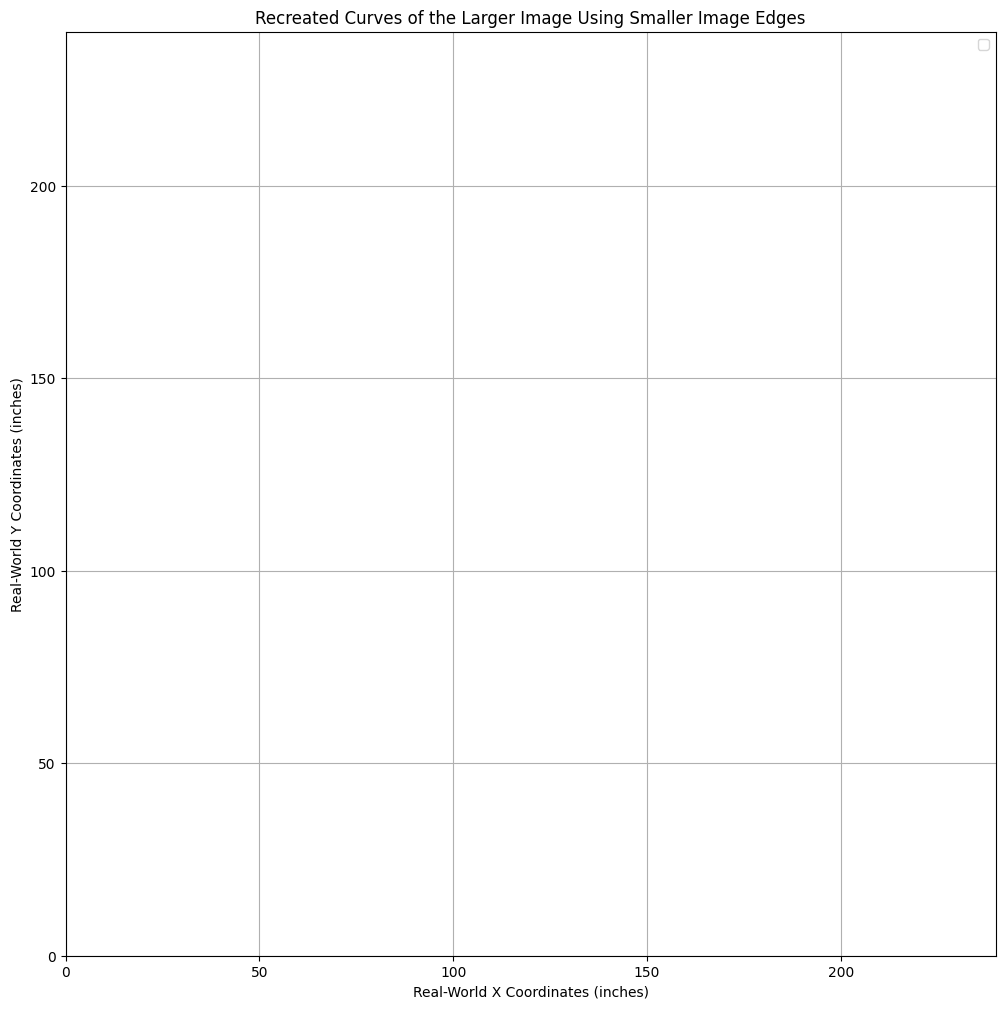

In [41]:
# Example usage
small_image_path = "test-cans/8.16x4.83/pepsi.png"
small_image_width = 8.16  # Width of the smaller image in inches
large_image_path = "test-images/muhammed.png"
large_image_width = 240  # Width of the larger image in inches
output_path = "output_mosaic.jpg"

# Specify a valid output folder for edge processing
output_folder = "output_folder_for_edges"
os.makedirs(output_folder, exist_ok=True)

# Process the smaller image to extract its edges
small_image_edges = process_image(small_image_path, output_folder=output_folder, real_distance=small_image_width)

# Pass the extracted edges to the function
create_mosaic_from_polynomial_curves(
    small_image_edges,  # Pass the edges of the smaller image
    large_image_path,
    large_image_width,
    lambda image_path, output_folder, real_distance: process_image(image_path, output_folder, real_distance)
)